In [1]:
from DemoTwin import WeldingDataset, HVDataset
import torch
from matplotlib import pyplot as plt
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
dataset = HVDataset()

dataloader = DataLoader(dataset)
batch = next(iter(dataloader))

In [3]:
df = dataset.get_file(0)
df

,Name,Abkühlrate in K/s,Anlasstemperatur in C,Haltedauer in min,Härte in HV1,Härte in HV1 (std)
0,0/0/0,0.00,0,0.00,340.6,3.07
1,"0,6/0/0",0.60,0,0.00,485.4,20.32
2,"0,6/400/30",0.60,400,30.00,394.4,16.05
3,"0,6/400/60",0.60,400,60.00,423.4,6.15
4,"0,6/400/120",0.60,400,120.00,424.6,10.17
5,"0,6/525/30",0.60,525,30.00,363.0,7.97
6,"0,6/525/60",0.60,525,60.00,358.8,4.17
7,"0,6/525/120",0.60,525,120.00,352.4,11.04
8,"0,6/650/30",0.60,650,30.00,283.0,3.95
9,"0,6/650/60",0.60,650,60.00,278.2,4.07


In [4]:
df_line = dataset.get_line(0, 12)
df_line

Name                     4/400/30
Abkühlrate in K/s             4.0
Anlasstemperatur in C         400
Haltedauer in min            30.0
Härte in HV1                493.4
Härte in HV1 (std)           3.93
Name: 12, dtype: object

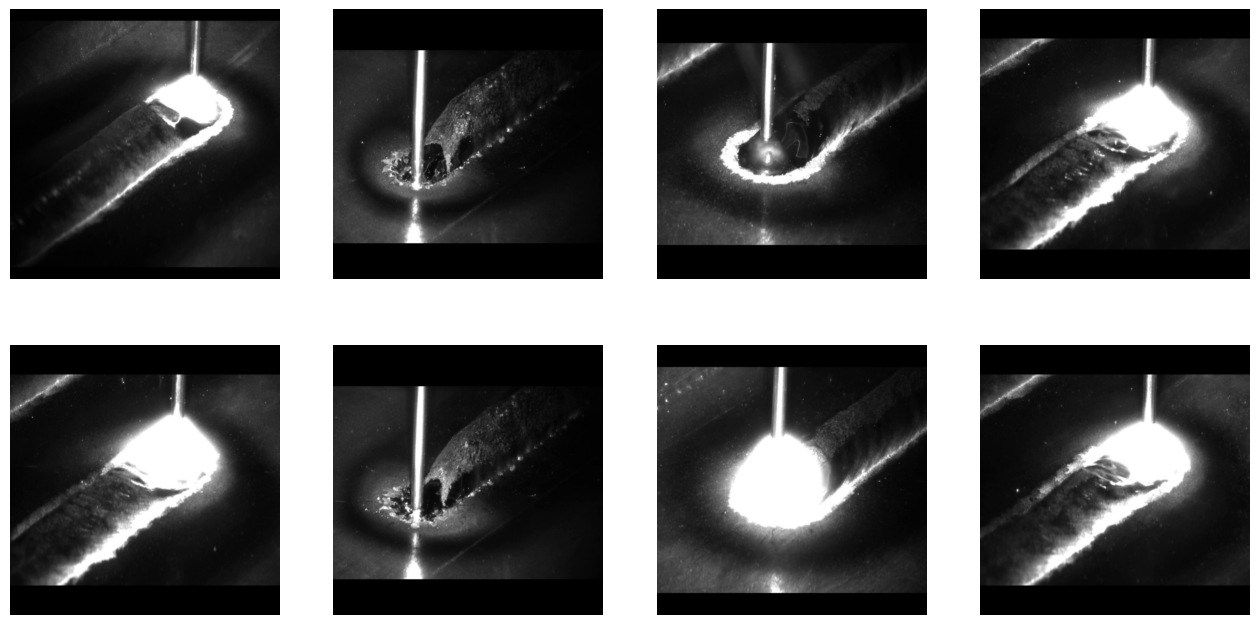

In [8]:
transform = v2.Compose([
    v2.Resize((512, 512)),
    v2.Grayscale(num_output_channels=1),
    # v2.ColorJitter(contrast=(2.0, 2.0)),
    # v2.RandomRotation(degrees=60),  # z.B. +-15°
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5])
])

dataset = WeldingDataset(transform=transform)

# Torch Like
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)

batch = next(iter(train_dataloader))
images = batch

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, img in enumerate(images[:8]):
    img_show = img * 0.5 + 0.5
    axes[i].imshow(img_show.permute(1, 2, 0), cmap="gray")
    axes[i].axis("off")